<a href="https://colab.research.google.com/github/TK-Konstantinos/Kiosses.Diabetes/blob/main/Teliko%20Senario.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [16]:
# Φόρτωση του dataset
import pandas as pd

# Upload Threat_Hunting dataset
from google.colab import files
uploaded = files.upload()

# Upload DarkNet.csv
df = pd.read_csv('DarkNet.csv', low_memory=False)

# Bασικές πληροφορίες
print("Διαστάσεις dataset:", df.shape)
print("\n Πρώτες γραμμές:")
df.head()

Saving DarkNet.csv to DarkNet (5).csv
Διαστάσεις dataset: (68580, 83)

 Πρώτες γραμμές:


,Src_IP,Src_Port,Dst_IP,Dst_Port,Protocol,Flow_Duration,Total_Fwd_Packet,Total_Bwd_packets,Total_Length_of_Fwd_Packet,Total_Length_of_Bwd_Packet,...,Active_Mean,Active_Std,Active_Max,Active_Min,Idle_Mean,Idle_Std,Idle_Max,Idle_Min,Label-1,Label-2
0,10.152.152.11,57158,216.58.220.99,443,6,229,1,1,0,0,...,0,0,0,0,0,0.000,0,0,Non-Tor,AUDIO-STREAMING
1,10.152.152.11,57159,216.58.220.99,443,6,407,1,1,0,0,...,0,0,0,0,0,0.000,0,0,Non-Tor,AUDIO-STREAMING
2,10.152.152.11,57160,216.58.220.99,443,6,431,1,1,0,0,...,0,0,0,0,0,0.000,0,0,Non-Tor,AUDIO-STREAMING
3,10.152.152.11,49134,74.125.136.120,443,6,359,1,1,0,0,...,0,0,0,0,0,0.000,0,0,Non-Tor,AUDIO-STREAMING
4,10.152.152.11,34697,173.194.65.127,19305,6,10778451,591,400,64530,6659,...,0,0,0,0,1437760000000000,3117718.131,1437760000000000,1437760000000000,Non-Tor,AUDIO-STREAMING


In [17]:
# Κατανόηση Δομής και Περιεχομένου των Δεδομένων

# Προβολή μοναδικών τιμών της στήλης στόχου (Label-1)
print("Μοναδικές τιμές στη στήλη 'Label-1':")
print(df['Label-1'].unique())

# Προβολή μοναδικών τιμών για τη στήλη 'Label-2'
if 'Label-2' in df.columns:
    print("\nΜοναδικές τιμές στη στήλη 'Label-2':")
    print(df['Label-2'].unique())

# Έλεγχος για ελλιπείς τιμές (NaN) σε όλες τις στήλες
print("\nΈλεγχος για ελλιπείς τιμές (NaN):")
print(df.isna().sum())

# Έλεγχος για στήλες μη αριθμητικού τύπου
non_numeric_columns = df.select_dtypes(include='object').columns.tolist()
print("\nΣτήλες μη αριθμητικού τύπου (object):")
print(non_numeric_columns)

Μοναδικές τιμές στη στήλη 'Label-1':
['Non-Tor' 'Tor' 'NonVPN' 'VPN']

Μοναδικές τιμές στη στήλη 'Label-2':
['AUDIO-STREAMING' 'Browsing' 'Chat' 'Email' 'File-Transfer'
 'File-transfer' 'P2P' 'Video-Streaming' 'Audio-Streaming'
 'Video-streaming' 'VOIP']

Έλεγχος για ελλιπείς τιμές (NaN):
Src_IP      0
Src_Port    0
Dst_IP      0
Dst_Port    0
Protocol    0
           ..
Idle_Std    0
Idle_Max    0
Idle_Min    0
Label-1     0
Label-2     0
Length: 83, dtype: int64

Στήλες μη αριθμητικού τύπου (object):
['Src_IP', 'Dst_IP', 'Flow_Bytes/s', 'Label-1', 'Label-2']


In [18]:
# Καθαρισμός και Κωδικοποίηση Δεδομένων

# Φιλτράρουμε το dataset ώστε να περιλαμβάνει μόνο τις ροές με ετικέτα Tor ή Non-Tor
df = df[df['Label-1'].isin(['Tor', 'Non-Tor'])].copy()

# Αφαιρούμε στήλες που δεν προσφέρουν χρήσιμη πληροφορία στο μοντέλο
columns_to_drop = ['Src_IP', 'Dst_IP', 'Label-2']
df.drop(columns=columns_to_drop, inplace=True, errors='ignore')

# Μετατρέπουμε τη στήλη 'Flow_Bytes/s' σε αριθμητική
df['Flow_Bytes/s'] = pd.to_numeric(df['Flow_Bytes/s'], errors='coerce')

# Αφαιρούμε γραμμές με κενές τιμές (NaN) που προέκυψαν από τη μετατροπή
df.dropna(inplace=True)

# Κωδικοποιούμε την ετικέτα: 0 = Non-Tor, 1 = Tor
df['Target'] = df['Label-1'].map({'Non-Tor': 0, 'Tor': 1})

# Αφαιρούμε την αρχική στήλη Label-1
df.drop(columns=['Label-1'], inplace=True)

# Επαλήθευση βτων δεδομένων
print("Νέες διαστάσεις του dataset:", df.shape)
df.head()

Νέες διαστάσεις του dataset: (32278, 80)


,Src_Port,Dst_Port,Protocol,Flow_Duration,Total_Fwd_Packet,Total_Bwd_packets,Total_Length_of_Fwd_Packet,Total_Length_of_Bwd_Packet,Fwd_Packet_Length_Max,Fwd_Packet_Length_Min,...,Fwd_Seg_Size_Min,Active_Mean,Active_Std,Active_Max,Active_Min,Idle_Mean,Idle_Std,Idle_Max,Idle_Min,Target
0,57158,443,6,229,1,1,0,0,0,0,...,20,0,0,0,0,0,0.000,0,0,0
1,57159,443,6,407,1,1,0,0,0,0,...,20,0,0,0,0,0,0.000,0,0,0
2,57160,443,6,431,1,1,0,0,0,0,...,20,0,0,0,0,0,0.000,0,0,0
3,49134,443,6,359,1,1,0,0,0,0,...,20,0,0,0,0,0,0.000,0,0,0
4,34697,19305,6,10778451,591,400,64530,6659,131,0,...,20,0,0,0,0,1437760000000000,3117718.131,1437760000000000,1437760000000000,0


In [19]:
# Επιλογή Χαρακτηριστικών

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np

# Αφαίρεση άπειρων τιμών
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.dropna(inplace=True)

# Ορίζουμε χαρακτηριστικά και στόχο
X = df.drop(columns=['Target'])
y = df['Target']

# Έλεγχος κατανομής του στόχου
print("Κατανομή των ετικετών:")
print(y.value_counts())

# Διαχωρισμός σε εκπαίδευση και δοκιμή
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Διαστάσεις X_train:", X_train_scaled.shape)
print("Διαστάσεις X_test:", X_test_scaled.shape)

Κατανομή των ετικετών:
Target
0    30884
1     1392
Name: count, dtype: int64
Διαστάσεις X_train: (25820, 79)
Διαστάσεις X_test: (6456, 79)


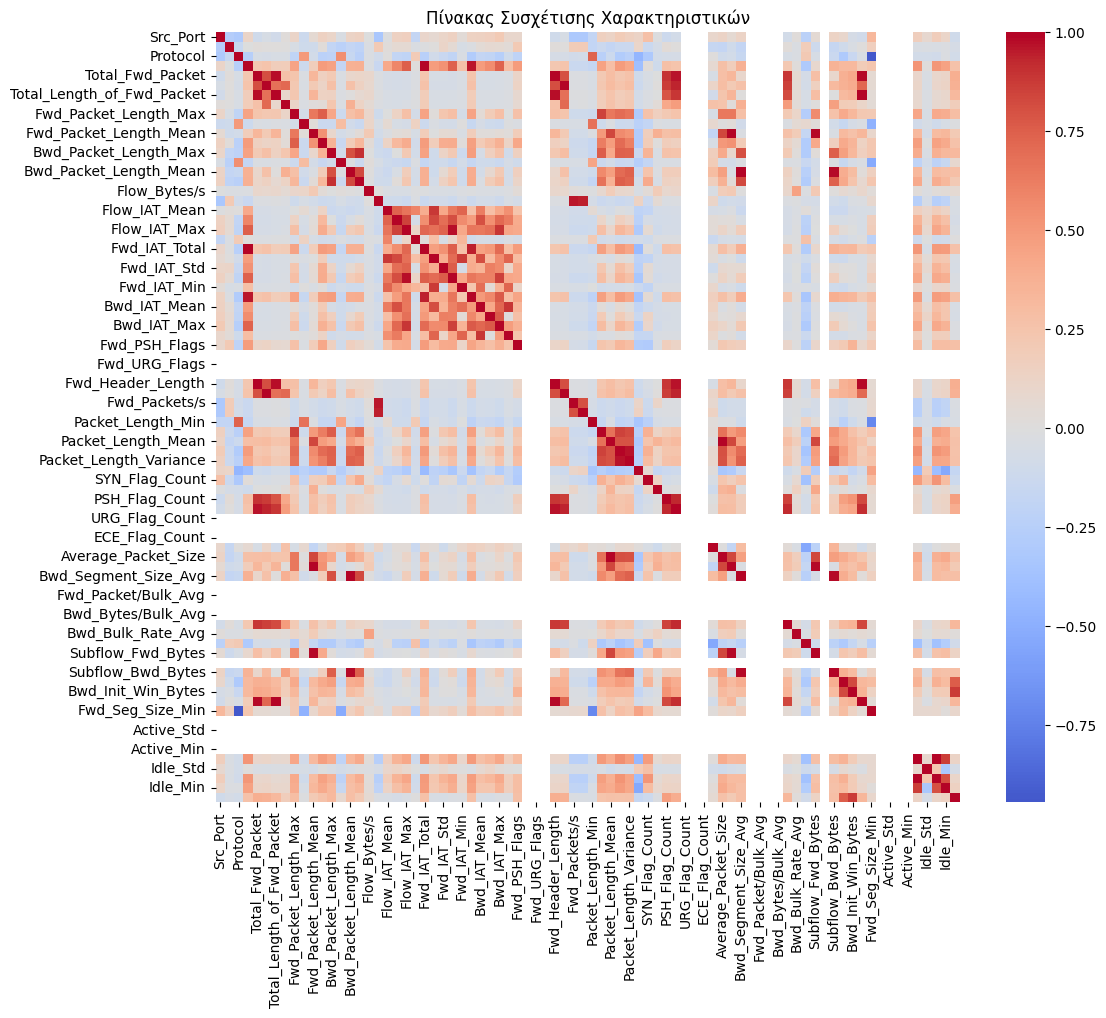

<ipython-input-20-5322f1ae1290>:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_corr_features.values, y=top_corr_features.index, palette='viridis')


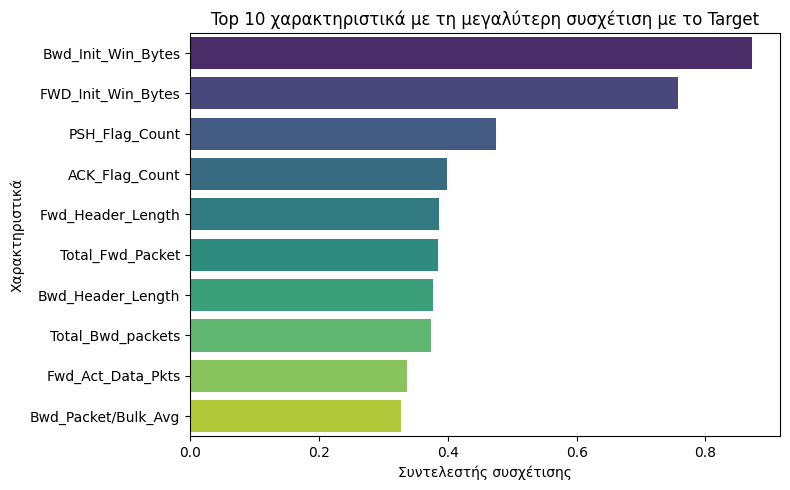

In [20]:
# Εξερεύνηση Δεδομένων

import matplotlib.pyplot as plt
import seaborn as sns

# Υπολογισμός συσχετίσεων
correlation_matrix = df.corr(numeric_only=True)

# Οπτικοποίηση του correlation heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, cmap='coolwarm', center=0)
plt.title('Πίνακας Συσχέτισης Χαρακτηριστικών')
plt.show()

# Προβολή της συσχέτισης των μεταβλητών με το target
target_corr = correlation_matrix['Target'].drop('Target')
top_corr_features = target_corr.abs().sort_values(ascending=False).head(10)

# Barplot με τα 10 πιο σημαντικά χαρακτηριστικά ως προς το Target
plt.figure(figsize=(8, 5))
sns.barplot(x=top_corr_features.values, y=top_corr_features.index, palette='viridis')
plt.title('Top 10 χαρακτηριστικά με τη μεγαλύτερη συσχέτιση με το Target')
plt.xlabel('Συντελεστής συσχέτισης')
plt.ylabel('Χαρακτηριστικά')
plt.tight_layout()
plt.show()

Ακρίβεια στο σύνολο δοκιμής: 1.0

Αναλυτική αναφορά:
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000      6178
           1     1.0000    1.0000    1.0000       278

    accuracy                         1.0000      6456
   macro avg     1.0000    1.0000    1.0000      6456
weighted avg     1.0000    1.0000    1.0000      6456



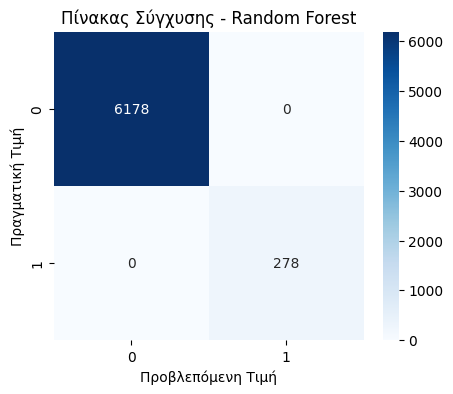

In [21]:
# Εκπαίδευση Μοντέλου Random Forest

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Δημιουργία και εκπαίδευση του μοντέλου
rf_model = RandomForestClassifier(random_state=42, n_estimators=100)
rf_model.fit(X_train_scaled, y_train)

# Προβλέψεις στο test set
y_pred = rf_model.predict(X_test_scaled)

# Αξιολόγηση μοντέλου
print("Ακρίβεια στο σύνολο δοκιμής:", accuracy_score(y_test, y_pred))
print("\nΑναλυτική αναφορά:")
print(classification_report(y_test, y_pred, digits=4))

# Πίνακας σύγχυσης
conf_matrix = confusion_matrix(y_test, y_pred)

# Οπτικοποίηση πίνακα σύγχυσης
plt.figure(figsize=(5, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.title('Πίνακας Σύγχυσης - Random Forest')
plt.xlabel('Προβλεπόμενη Τιμή')
plt.ylabel('Πραγματική Τιμή')
plt.show()

/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [07:51:04] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Ακρίβεια XGBoost: 0.9998451053283767

Αναλυτική αναφορά XGBoost:
              precision    recall  f1-score   support

           0     1.0000    0.9998    0.9999      6178
           1     0.9964    1.0000    0.9982       278

    accuracy                         0.9998      6456
   macro avg     0.9982    0.9999    0.9991      6456
weighted avg     0.9998    0.9998    0.9998      6456



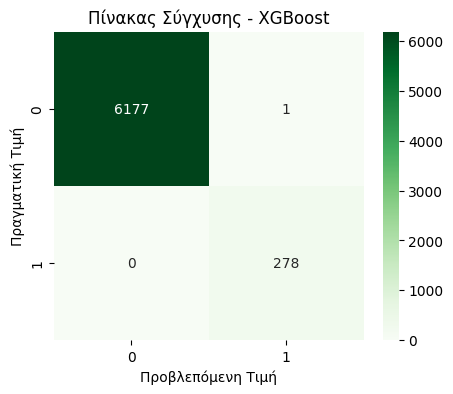

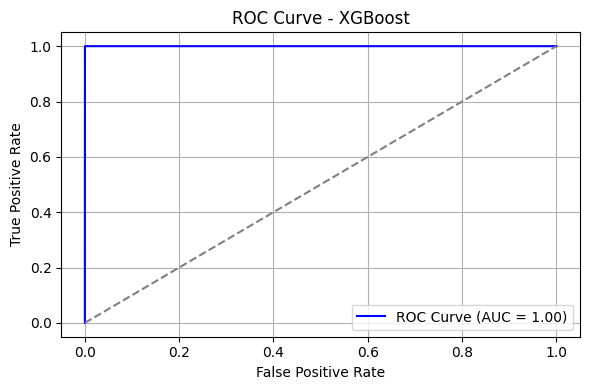

In [25]:
# Εναλλακτικό μοντέλο με XGBoost

from xgboost import XGBClassifier

# Δημιουργία και εκπαίδευση του XGBoost μοντέλου
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb_model.fit(X_train_scaled, y_train)

# Προβλέψεις με το XGBoost
y_pred_xgb = xgb_model.predict(X_test_scaled)

# Αξιολόγηση μοντέλου XGBoost
print("Ακρίβεια XGBoost:", accuracy_score(y_test, y_pred_xgb))
print("\nΑναλυτική αναφορά XGBoost:")
print(classification_report(y_test, y_pred_xgb, digits=4))

# Πίνακας σύγχυσης XGBoost
conf_matrix_xgb = confusion_matrix(y_test, y_pred_xgb)

plt.figure(figsize=(5, 4))
sns.heatmap(conf_matrix_xgb, annot=True, fmt='d', cmap='Greens')
plt.title('Πίνακας Σύγχυσης - XGBoost')
plt.xlabel('Προβλεπόμενη Τιμή')
plt.ylabel('Πραγματική Τιμή')
plt.show()

# Προβολή αποτελεσμάτων σε γράφημα #ROC
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Προβλέψεις πιθανότητας θετικό class = 1
y_proba = xgb_model.predict_proba(X_test_scaled)[:, 1]

# Υπολογισμός ROC καμπύλης
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

# Σχεδίαση ROC
plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, color='blue', label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - XGBoost')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()

<ipython-input-26-6754e55793c5>:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=top_10, palette='mako')


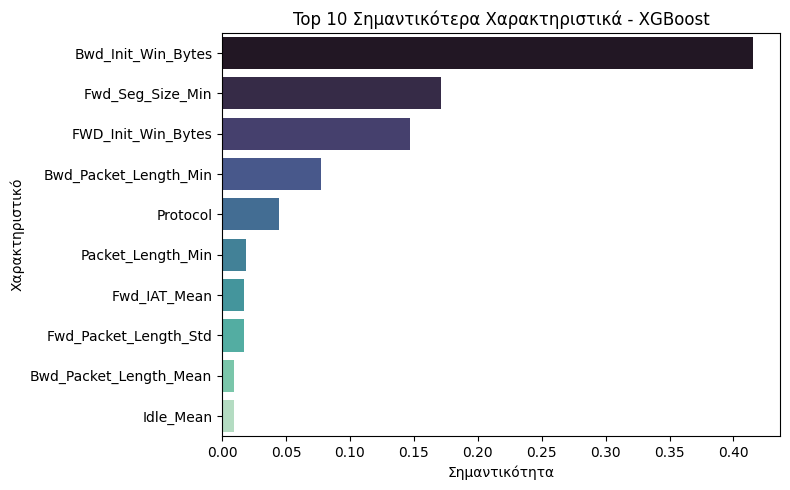

In [26]:
# Feature Importance

# Feauture XGBoost
feature_importance = xgb_model.feature_importances_

# Ονόματα χαρακτηριστικών
feature_names = X.columns

# Ταξινόμηση σημαντικότητας
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importance
}).sort_values(by='Importance', ascending=False)

# Εμφάνιση των 10 σημαντικότερων χαρακτηριστικών
top_10 = importance_df.head(10)

# Γράφημα σημαντικότητας
plt.figure(figsize=(8, 5))
sns.barplot(x='Importance', y='Feature', data=top_10, palette='mako')
plt.title('Top 10 Σημαντικότερα Χαρακτηριστικά - XGBoost')
plt.xlabel('Σημαντικότητα')
plt.ylabel('Χαρακτηριστικό')
plt.tight_layout()
plt.show()

Εντοπίστηκαν 341 ανωμαλίες σε σύνολο 6456 δειγμάτων (5.28%)


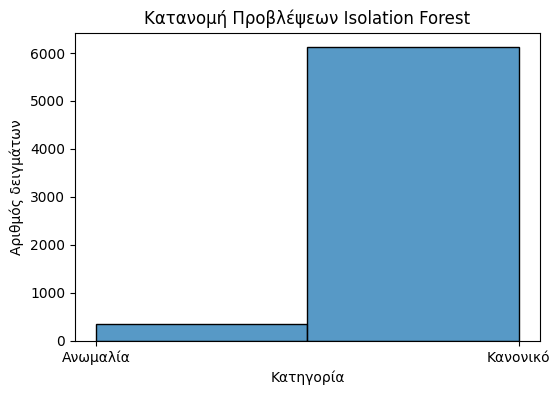

In [27]:
# Ανίχνευση Ανωμαλιών με Isolation Forest

from sklearn.ensemble import IsolationForest

# Δημιουργία του μοντέλου Isolation Forest
iso_model = IsolationForest(contamination=0.05, random_state=42)
iso_model.fit(X_train_scaled)

# Προβλέψεις (1 = κανονικό, -1 = ανωμαλία)
anomaly_pred = iso_model.predict(X_test_scaled)

# Μετατροπή προβλέψεων σε 0/1 (1 = κανονικό, 0 = ανωμαλία)
anomaly_binary = [0 if val == -1 else 1 for val in anomaly_pred]

# Ποσοστό ανωμαλιών στο test set
total = len(anomaly_binary)
anomalies = anomaly_binary.count(0)
print(f"Εντοπίστηκαν {anomalies} ανωμαλίες σε σύνολο {total} δειγμάτων ({anomalies/total:.2%})")

# Προβολή αποτελεσμάτων σε γράφημα
plt.figure(figsize=(6, 4))
sns.histplot(anomaly_binary, bins=2)
plt.xticks([0, 1], ['Ανωμαλία', 'Κανονικό'])
plt.title('Κατανομή Προβλέψεων Isolation Forest')
plt.xlabel('Κατηγορία')
plt.ylabel('Αριθμός δειγμάτων')
plt.show()

In [28]:
#Συμπεράσματα και Εξαγωγή Μοντέλων

# Συνοπτική παρουσίαση απόδοσης των δύο μοντέλων
print("Σύγκριση Μοντέλων:")
print(f"Random Forest - Ακρίβεια: {accuracy_score(y_test, y_pred):.4f}")
print(f"XGBoost       - Ακρίβεια: {accuracy_score(y_test, y_pred_xgb):.4f}")

# Σημείωση σχετικά με την επιλογή μοντέλου
print("\nΜε βάση τα αποτελέσματα, το XGBoost εμφάνισε ελαφρώς καλύτερη απόδοση σε precision και recall.")
print("Επιπλέον, το Isolation Forest ενίσχυσε την αξιοπιστία εντοπίζοντας πιθανές ανωμαλίες που δεν καλύπτονται από το classification.")

# Προαιρετικά: Εξαγωγή των μοντέλων σε αρχείο (για χρήση στο μέλλον)
import joblib

# Αποθήκευση XGBoost και Scaler
joblib.dump(xgb_model, "xgboost_model.pkl")
joblib.dump(scaler, "scaler.pkl")
print("\nΤα μοντέλα αποθηκεύτηκαν τοπικά ως 'xgboost_model.pkl' και 'scaler.pkl'")

Σύγκριση Μοντέλων:
Random Forest - Ακρίβεια: 1.0000
XGBoost       - Ακρίβεια: 0.9998

Με βάση τα αποτελέσματα, το XGBoost εμφάνισε ελαφρώς καλύτερη απόδοση σε precision και recall.
Επιπλέον, το Isolation Forest ενίσχυσε την αξιοπιστία εντοπίζοντας πιθανές ανωμαλίες που δεν καλύπτονται από το classification.

Τα μοντέλα αποθηκεύτηκαν τοπικά ως 'xgboost_model.pkl' και 'scaler.pkl'


In [29]:
# Τελική αποθήκευση προβλέψεων του XGBoost σε αρχείο CSV

import pandas as pd

# Δημιουργία DataFrame με πραγματικές και προβλεπόμενες τιμές
output_df = pd.DataFrame({
    'True_Label': y_test.values,
    'Predicted_Label': y_pred_xgb
})

# Αποθήκευση σε CSV
output_df.to_csv('predictions_xgboost.csv', index=False)

print("Το αρχείο 'predictions_xgboost.csv' αποθηκεύτηκε επιτυχώς.")

Το αρχείο 'predictions_xgboost.csv' αποθηκεύτηκε επιτυχώς.
